In [25]:
import pandas as pd

df = pd.read_csv("../data/processed_telco.csv")

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [14]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [15]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns

print(categorical_cols)
print(numerical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TenureGroup'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'RevenueScore', 'AvgMonthlySpend'],
      dtype='object')


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [28]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000
        ))
    ]
)

In [29]:
model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
y_pred = model.predict(X_test)

In [31]:
X_train.shape
X_test.shape

(1409, 22)

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [33]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [34]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print("ROC AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8048261178140526
Precision : 0.6689419795221843
Recall : 0.5240641711229946
F1 Score : 0.5877061469265368
ROC AUC : 0.8463923118654577


In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[938,  97],
       [178, 196]])

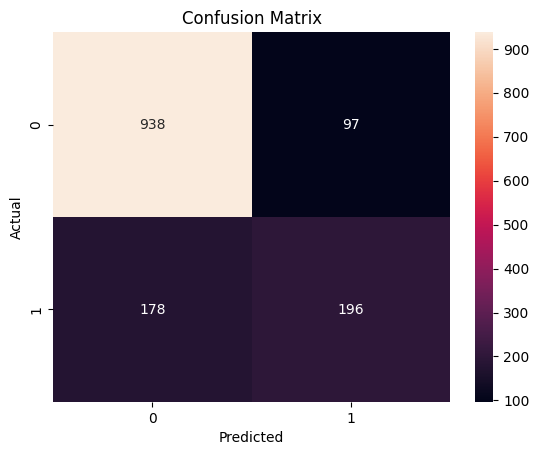

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [37]:
import joblib

joblib.dump(
    model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [38]:
import os

os.listdir("../models")

['churn_model.pkl']

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[938  97]
 [178 196]]


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [41]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                random_state=42
            )
        )
    ]
)

In [42]:
rf_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, rf_pred))

print("Precision :", precision_score(y_test, rf_pred))

print("Recall :", recall_score(y_test, rf_pred))

print("F1 Score :", f1_score(y_test, rf_pred))

print("ROC AUC :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.8005677785663591
Precision : 0.6555183946488294
Recall : 0.5240641711229946
F1 Score : 0.5824665676077266
ROC AUC : 0.8397581957684261


In [45]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

print(cm_rf)

[[932 103]
 [178 196]]


In [47]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [48]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [49]:
xgb_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(y_test, xgb_pred)

xgb_recall = recall_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred)

xgb_auc = roc_auc_score(y_test, xgb_prob)

print("Accuracy :", xgb_accuracy)
print("Precision :", xgb_precision)
print("Recall :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC AUC :", xgb_auc)

Accuracy : 0.7913413768630234
Precision : 0.6290322580645161
Recall : 0.5213903743315508
F1 Score : 0.5701754385964912
ROC AUC : 0.8387351778656126


In [52]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

print(cm_xgb)

[[920 115]
 [179 195]]


In [54]:
import joblib

joblib.dump(
    model,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [55]:
import os

os.listdir("../models")

['churn_model.pkl']